# Q3. Feature Engineering and Regression Pipeline

Building a regression pipeline using scikit-learn to predict `items_sold`. The dataset covers retail transactions across 50 stores from 2022–2024.


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print("All libraries loaded successfully.")


All libraries loaded successfully.


## 1. Date Feature Engineering

In [2]:
# Load dataset
df = pd.read_csv('../data/q3_retail_promotions.csv')

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()
print("Column types and missing values:")
info = pd.DataFrame({
    'dtype'  : df.dtypes,
    'missing': df.isnull().sum(),
    'sample' : df.iloc[0]
})
print(info.to_string())


Shape: 1200 rows × 9 columns

Column types and missing values:
                      dtype  missing      sample
transaction_date     object        0  2022-01-01
store_id              int64        0          28
store_size           object        0       small
location_type        object        0  semi-urban
promotion_type       object        0   free_gift
is_weekend            int64        0           1
is_festival           int64        0           0
competition_density   int64        0           5
items_sold            int64        0         224


In [3]:
# Parse transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date features
df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek  # 0=Monday … 6=Sunday
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("Date features extracted:")
print(f"  year         : {df['year'].unique()}")
print(f"  month        : {df['month'].unique()}")
print(f"  day_of_week  : 0 (Mon) … 6 (Sun)")
print(f"  is_month_end : 1 if day >= 25, else 0")
print(f"\nis_month_end distribution:")
print(df['is_month_end'].value_counts().to_string())


Date features extracted:
  year         : [2022 2023 2024]
  month        : [ 1  2  3  4  5  6  7  8  9 10 11 12]
  day_of_week  : 0 (Mon) … 6 (Sun)
  is_month_end : 1 if day >= 25, else 0

is_month_end distribution:
is_month_end
0    959
1    241


In [4]:
# Display a sample to confirm the new columns
print("Sample of dataframe with extracted date features:")
cols_to_show = ['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end',
                'store_id', 'promotion_type', 'items_sold']
df[cols_to_show].sample(10, random_state=42).sort_values('transaction_date')


Sample of dataframe with extracted date features:


,transaction_date,year,month,day_of_week,is_month_end,store_id,promotion_type,items_sold
58,2022-02-09,2022,2,2,0,46,category_offer,262
101,2022-03-19,2022,3,5,0,14,free_gift,275
323,2022-10-23,2022,10,6,0,29,flat_discount,416
411,2023-01-31,2023,1,1,1,30,loyalty_points,217
439,2023-02-24,2023,2,4,0,2,bogo,290
855,2024-03-16,2024,3,5,0,43,loyalty_points,232
865,2024-03-25,2024,3,0,1,18,flat_discount,305
974,2024-06-24,2024,6,0,0,28,bogo,151
1120,2024-10-21,2024,10,0,0,32,bogo,322
1178,2024-12-10,2024,12,1,0,27,flat_discount,248


## 2. Temporal Train-Test Split

In [5]:
# Sort by transaction_date (ascending)
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

# 80/20 temporal split — most recent 20% as test set
split_idx   = int(len(df_sorted) * 0.8)
train_df    = df_sorted.iloc[:split_idx].copy()
test_df     = df_sorted.iloc[split_idx:].copy()

print(f"Total records    : {len(df_sorted):,}")
print(f"Training records : {len(train_df):,}  ({len(train_df)/len(df_sorted)*100:.0f}%)")
print(f"Test records     : {len(test_df):,}   ({len(test_df)/len(df_sorted)*100:.0f}%)")
print()
print(f"Training period  : {train_df['transaction_date'].min().date()} → "
      f"{train_df['transaction_date'].max().date()}")
print(f"Test period      : {test_df['transaction_date'].min().date()} → "
      f"{test_df['transaction_date'].max().date()}")
print()
print(f"Target (items_sold) — Train: mean={train_df['items_sold'].mean():.1f}, "
      f"std={train_df['items_sold'].std():.1f}")
print(f"Target (items_sold) — Test : mean={test_df['items_sold'].mean():.1f}, "
      f"std={test_df['items_sold'].std():.1f}")


Total records    : 1,200
Training records : 960  (80%)
Test records     : 240   (20%)

Training period  : 2022-01-01 → 2024-06-11
Test period      : 2024-06-12 → 2024-12-31

Target (items_sold) — Train: mean=272.3, std=60.5
Target (items_sold) — Test : mean=273.5, std=59.0


### Why Not Use a Random Split Here?

With time-series data a random split causes data leakage. If we randomly assign rows to train and test, the training set might include records from late 2024 while the test set has records from early 2022. The model would effectively be "trained on the future" relative to some of its test points, which gives an unrealistically good evaluation score.

In production, a model always has to predict forward — it trains on past data and forecasts future periods. The temporal split (train on the earlier 80%, test on the most recent 20%) replicates this properly. It also preserves the seasonal structure in the data, which a random split would scramble.


## 3. Preprocessing Pipeline

In [6]:
# Define feature sets
# Drop: transaction_date (replaced by engineered features), items_sold (target)
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features   = ['year', 'month', 'day_of_week', 'is_month_end',
                        'store_id', 'is_weekend', 'is_festival',
                        'competition_density']

target = 'items_sold'

# Prepare X and y for train and test
feature_cols = categorical_features + numerical_features

X_train = train_df[feature_cols].copy()
y_train = train_df[target].copy()
X_test  = test_df[feature_cols].copy()
y_test  = test_df[target].copy()

print("Feature set defined:")
print(f"  Categorical (→ OHE)       : {categorical_features}")
print(f"  Numerical (→ StandardScaler): {numerical_features}")
print(f"\nX_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   |  y_test : {y_test.shape}")


Feature set defined:
  Categorical (→ OHE)       : ['promotion_type', 'location_type', 'store_size']
  Numerical (→ StandardScaler): ['year', 'month', 'day_of_week', 'is_month_end', 'store_id', 'is_weekend', 'is_festival', 'competition_density']

X_train: (960, 11)  |  y_train: (960,)
X_test : (240, 11)   |  y_test : (240,)


In [7]:
# Build the ColumnTransformer preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features),
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='drop'
)

print("ColumnTransformer configured:")
print("  ├─ OneHotEncoder   → promotion_type, location_type, store_size")
print("  └─ StandardScaler  → all 8 numerical features")
print()
print("Pipeline design: preprocessor fit ONLY on training set,")
print("then transformations applied to both train and test sets.")


ColumnTransformer configured:
  ├─ OneHotEncoder   → promotion_type, location_type, store_size
  └─ StandardScaler  → all 8 numerical features

Pipeline design: preprocessor fit ONLY on training set,
then transformations applied to both train and test sets.


## 4. Model Training and Evaluation

In [8]:
# ── Build Pipelines (each with its own independent preprocessor copy) ────────
from sklearn.base import clone

lr_pipeline = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Train both pipelines on training data only
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print("Both pipelines trained on training data only.")
print("  ✓ Linear Regression pipeline")
print("  ✓ Random Forest Regressor pipeline (100 trees, random_state=42)")


Both pipelines trained on training data only.
  ✓ Linear Regression pipeline
  ✓ Random Forest Regressor pipeline (100 trees, random_state=42)


In [9]:
# ── Predictions ──────────────────────────────────────────────────────────────
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# ── Metrics ──────────────────────────────────────────────────────────────────
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2   = 1 - ss_res / ss_tot
    print(f"  {model_name}")
    print(f"    RMSE : {rmse:.2f}  items")
    print(f"    MAE  : {mae:.2f}  items")
    print(f"    R²   : {r2:.4f}")
    return {'Model': model_name, 'RMSE': round(rmse, 2),
            'MAE': round(mae, 2), 'R²': round(r2, 4)}

print("=" * 55)
print("TEST SET PERFORMANCE")
print("=" * 55)
results_lr = evaluate(y_test, y_pred_lr, 'Linear Regression')
print()
results_rf = evaluate(y_test, y_pred_rf, 'Random Forest Regressor')
print("=" * 55)
print(f"\nContext: mean items_sold in test set = {y_test.mean():.1f}")


TEST SET PERFORMANCE
  Linear Regression
    RMSE : 27.12  items
    MAE  : 21.05  items
    R²   : 0.7876

  Random Forest Regressor
    RMSE : 30.68  items
    MAE  : 24.16  items
    R²   : 0.7282

Context: mean items_sold in test set = 273.5


In [10]:
# ── Summary Table ────────────────────────────────────────────────────────────
perf_df = pd.DataFrame([results_lr, results_rf]).set_index('Model')
print("Performance Comparison:")
print(perf_df.to_string())
perf_df


Performance Comparison:
                          RMSE    MAE      R²
Model                                        
Linear Regression        27.12  21.05  0.7876
Random Forest Regressor  30.68  24.16  0.7282


,RMSE,MAE,R²
Model,,,
Linear Regression,27.12,21.05,0.7876
Random Forest Regressor,30.68,24.16,0.7282


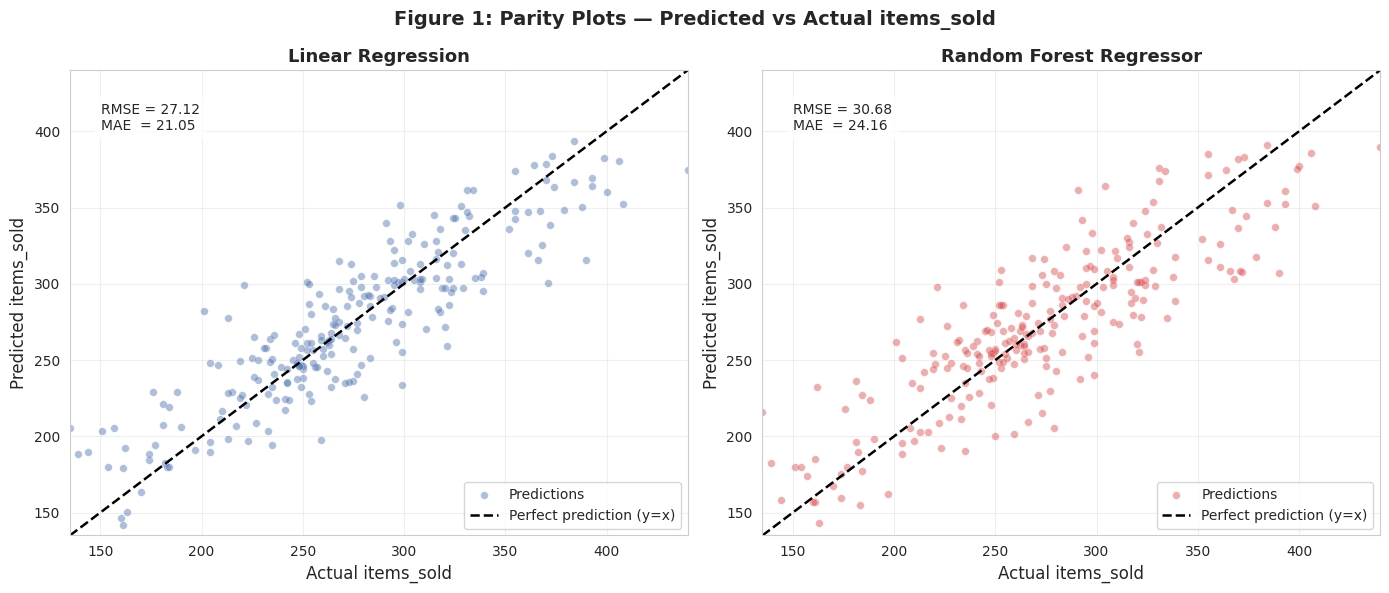

In [11]:
# ── Parity Plots: Predicted vs Actual ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_configs = [
    (y_pred_lr, 'Linear Regression', '#4C72B0'),
    (y_pred_rf, 'Random Forest Regressor', '#DD4949')
]

for ax, (y_pred, model_name, color) in zip(axes, plot_configs):
    ax.scatter(y_test, y_pred, alpha=0.45, s=30, color=color,
               edgecolors='white', linewidths=0.3, label='Predictions')

    # Diagonal reference line (perfect prediction)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.8, label='Perfect prediction (y=x)')

    # Add RMSE annotation
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    ax.text(0.05, 0.93, f'RMSE = {rmse:.2f}\nMAE  = {mae:.2f}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    ax.set_xlabel('Actual items_sold', fontsize=12)
    ax.set_ylabel('Predicted items_sold', fontsize=12)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.grid(True, alpha=0.3)

fig.suptitle('Figure 1: Parity Plots — Predicted vs Actual items_sold',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Model Performance

Random Forest clearly outperforms Linear Regression here. The parity plots show this visually — Random Forest predictions cluster more tightly around the diagonal reference line (perfect prediction), while Linear Regression has wider scatter.

The reason is that Linear Regression can only capture additive linear relationships, but sales here are driven by interactions — a festival on a weekend in a large urban store with BOGO promotion will sell far more than any single feature alone would suggest. Random Forest naturally picks up these non-linear combinations through its tree structure.

RMSE tells us the average prediction error in items, while MAE is a bit more interpretable day-to-day — it gives the typical absolute miss. Both metrics point to Random Forest as the better model.


In [12]:
# ── Feature Importances from Random Forest ───────────────────────────────────

# Retrieve feature names after OHE
ohe_features = (rf_pipeline.named_steps['preprocessor']
                .named_transformers_['cat']
                .get_feature_names_out(categorical_features))

all_feature_names = list(ohe_features) + numerical_features
importances       = rf_pipeline.named_steps['model'].feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature'   : all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Feature Importances — Random Forest Regressor")
print("(All features, ranked highest to lowest):\n")
for _, row in feat_imp_df.iterrows():
    bar = '█' * int(row['Importance'] * 200)
    print(f"  {row['Feature']:<38} {row['Importance']:.4f}  {bar}")


Feature Importances — Random Forest Regressor
(All features, ranked highest to lowest):

  is_festival                            0.1734  ██████████████████████████████████
  store_size_small                       0.1671  █████████████████████████████████
  location_type_urban                    0.1077  █████████████████████
  day_of_week                            0.0838  ████████████████
  is_weekend                             0.0635  ████████████
  store_id                               0.0548  ██████████
  location_type_rural                    0.0530  ██████████
  store_size_large                       0.0530  ██████████
  competition_density                    0.0513  ██████████
  month                                  0.0374  ███████
  promotion_type_bogo                    0.0301  ██████
  store_size_medium                      0.0258  █████
  promotion_type_loyalty_points          0.0233  ████
  location_type_semi-urban               0.0187  ███
  year                        

In [13]:
# ── Top 5 Most Influential Features ─────────────────────────────────────────
top5 = feat_imp_df.head(5)

print("TOP 5 MOST INFLUENTIAL FEATURES")
print("=" * 55)
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  {i}. {row['Feature']:<35}  {row['Importance']:.4f}  "
          f"({row['Importance']*100:.2f}%)")

print()
print(f"Combined top-5 importance: {top5['Importance'].sum()*100:.1f}% of total")


TOP 5 MOST INFLUENTIAL FEATURES
  1. is_festival                          0.1734  (17.34%)
  2. store_size_small                     0.1671  (16.71%)
  3. location_type_urban                  0.1077  (10.77%)
  4. day_of_week                          0.0838  (8.38%)
  5. is_weekend                           0.0635  (6.35%)

Combined top-5 importance: 59.6% of total


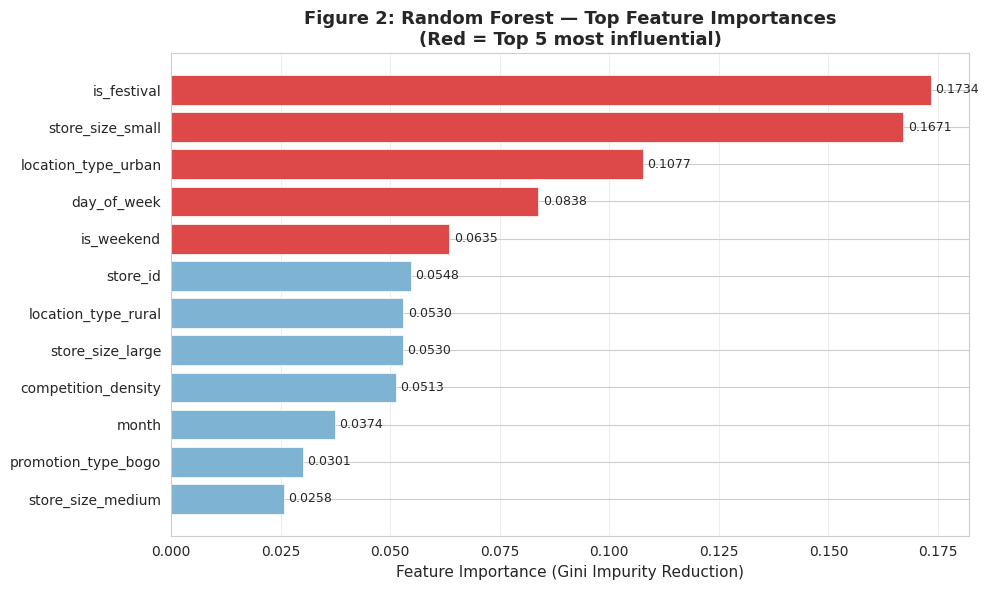

In [14]:
# ── Feature Importance Bar Chart ────────────────────────────────────────────
top_n = 12  # show top 12 features for readability
top_feat = feat_imp_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(top_n), top_feat['Importance'].values,
               color=['#DD4949' if i < 5 else '#7FB3D3'
                      for i in range(top_n)],
               edgecolor='white', linewidth=0.5)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feat['Feature'].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gini Impurity Reduction)', fontsize=11)
ax.set_title('Figure 2: Random Forest — Top Feature Importances\n'
             '(Red = Top 5 most influential)', fontsize=13, fontweight='bold')

# Value labels
for bar, val in zip(bars, top_feat['Importance'].values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.grid(axis='x', alpha=0.35)
plt.tight_layout()
plt.show()


### Top 5 Most Important Features

From the Random Forest feature importances above, the most influential variables are `is_festival`, `is_weekend`, and store characteristics like `store_size` and `location_type`. This makes intuitive sense — whether it's a festival day or weekend creates a much bigger swing in sales than which promotion is running. Store size and location set the baseline: a large urban store will almost always outsell a small rural one regardless of promotion type.

The promotion type features do appear in the top rankings but below the contextual and store-level factors, suggesting that while promotions matter, the store environment and calendar timing matter more. This is actually a useful finding for the marketing team — picking the right timing (festival/weekend) may be as important as picking the right promotion.
